In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

In [2]:
df = pd.read_csv(r'd:\SMS6.csv', header=None)

In [3]:
df.head()

,0,1,2,3,4,5,6,7
0,SMS,receive,22865,22865.1,date,321,SPAM,messages
1,SMS,receive,22865,22865,5/8/2014 11:09,321,SPAM,HEALTH is the greatest gift. A healthy outside...
2,SMS,receive,22865,22865,29/07/2014 12:19,321,SPAM,Do you know Ebola kills up to 90% of infected ...
3,SMS,receive,22865,22865,10/7/2014 11:16,321,SPAM,Enjoy latest films from all cinemas on your ph...
4,SMS,receive,MTN N,MTN N,8/8/2014 10:35,119,SPAM,Get the new MTN Android Smartphones for as low...


In [4]:
labels = df[6].values
messages = df[7].values

valid_col = [(l, m) for l, m in zip(labels, messages)    
             if l in ('HAM', 'SPAM') and isinstance(m, str)] # filter out invalid rows

# quick way to unzip the list of tuples into separate lists
labels, messages = zip(*valid_col)

In [5]:
len(labels), len(messages)

(1082, 1082)

In [6]:
def clean(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text) # Remove digits
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra whitespace
    return text

messages = [clean(t) for t in messages]

label = np.array([1 if l == 'SPAM' else 0 for l in labels])


In [7]:
messages

['messages',
 'health is the greatest gift a healthy outside starts from the inside get daily health tips for preventable diseases send health to nweek',
 'do you know ebola kills up to of infected peoplethere is no vaccination there is no cure send health to to get daily health tips on ebola virus',
 'enjoy latest films from all cinemas on your phone get daily movie alerts delivered on your phone send movie to n weekly now',
 'get the new mtn android smartphones for as low as n',
 'music is food to the soul to get amin by dammy krane',
 'yello get fast',
 'stream the latest video',
 'oya ladies',
 'get mins voice calls',
 'yelloget the latest african hit tracks more with the hottest music app',
 'yello get fast',
 'get mins voice calls',
 'loose belly fat in days send diet to to subscribe for daily tips at n only',
 'do you know the fastest way to lose weight send diet to to discover painless tips at n daily',
 'loose belly fat in days send diet to to subscribe for daily tips at n onl

## Build a vocabulary & feature matrix

Assign index to new word 

In [8]:
# Build vocabulary
vocab = {}
idx = 0
for msg in messages: 	
    for word in msg.split():
        if word not in vocab:
            vocab[word] = idx # Assign index to new word
            idx += 1 	# Increment index for new word
            
(vocab), len(vocab)

({'messages': 0,
  'health': 1,
  'is': 2,
  'the': 3,
  'greatest': 4,
  'gift': 5,
  'a': 6,
  'healthy': 7,
  'outside': 8,
  'starts': 9,
  'from': 10,
  'inside': 11,
  'get': 12,
  'daily': 13,
  'tips': 14,
  'for': 15,
  'preventable': 16,
  'diseases': 17,
  'send': 18,
  'to': 19,
  'nweek': 20,
  'do': 21,
  'you': 22,
  'know': 23,
  'ebola': 24,
  'kills': 25,
  'up': 26,
  'of': 27,
  'infected': 28,
  'peoplethere': 29,
  'no': 30,
  'vaccination': 31,
  'there': 32,
  'cure': 33,
  'on': 34,
  'virus': 35,
  'enjoy': 36,
  'latest': 37,
  'films': 38,
  'all': 39,
  'cinemas': 40,
  'your': 41,
  'phone': 42,
  'movie': 43,
  'alerts': 44,
  'delivered': 45,
  'n': 46,
  'weekly': 47,
  'now': 48,
  'new': 49,
  'mtn': 50,
  'android': 51,
  'smartphones': 52,
  'as': 53,
  'low': 54,
  'music': 55,
  'food': 56,
  'soul': 57,
  'amin': 58,
  'by': 59,
  'dammy': 60,
  'krane': 61,
  'yello': 62,
  'fast': 63,
  'stream': 64,
  'video': 65,
  'oya': 66,
  'ladies': 67,


## Feature matrix - convert text to numbers by counting words 

- Using bag of word
- X[i, vocab[word]] += 1

In [9]:
# to check how often each word appears in each message and create a feature matrix
X = np.zeros((len(messages), len(vocab)), dtype=int) 

for i, msg in enumerate(messages):
	for word in msg.split():
		if word in vocab:
			X[i, vocab[word]] += 1
y = label.reshape(-1, 1)

X, y

(array([[1, 0, 0, ..., 0, 0, 0],
        [0, 3, 1, ..., 0, 0, 0],
        [0, 2, 2, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 0, 0, 0]], shape=(1082, 2164)),
 array([[1],
        [1],
        [1],
        ...,
        [0],
        [0],
        [0]], shape=(1082, 1)))

In [10]:
np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))

X_train, X_test = X[indices[:split]], X[indices[split:]]
y_train, y_test = y[indices[:split]], y[indices[split:]]

tra_max = X_train.max(axis=0) + 1e-8
X_train = X_train / tra_max
X_test  = X_test / tra_max

print(f"train: {X_train.shape}, test: {X_test.shape}")


train: (865, 2164), test: (217, 2164)


In [20]:
# Sigmoid function
def sigmoid(z):
    z = np.clip(z, -500, 500)  # prevent overflow
    return 1 / (1 + np.exp(-z))

# Cost function (Binary Cross Entropy)
def cost_function(X, y, w, b):
    m = len(y)
    z = X @ w + b
    h = sigmoid(z)
    h = np.clip(h, 1e-8, 1 - 1e-8)  # avoid log(0)
    cost = -(1/m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return cost

# Gradient Descent
def gradient_descent(X, y, w, b, alpha, iter):
    m = len(y)
    cost_history = []

    for i in range(iter):
        z = X @ w + b
        h = sigmoid(z)

        # Gradients
        dw = (1/m) * (X.T @ (h - y))
        db = (1/m) * np.sum(h - y)

        # Update weights
        w = w - alpha * dw
        b = b - alpha * db

        # Track cost
        cost = cost_function(X, y, w, b)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"iter {i}: Cost = {cost:.4f}")

    return w, b, cost_history

# Initialize weights
n_features = X_train.shape[1]
w = np.zeros((n_features, 1))
b = 0

# Train
alpha = 0.5
n_iter = 10000

w, b, cost_history = gradient_descent(X_train, y_train, w, b, alpha, n_iter)

iter 0: Cost = 0.6746
iter 100: Cost = 0.4123
iter 200: Cost = 0.3473
iter 300: Cost = 0.3102
iter 400: Cost = 0.2847
iter 500: Cost = 0.2655
iter 600: Cost = 0.2502
iter 700: Cost = 0.2377
iter 800: Cost = 0.2271
iter 900: Cost = 0.2180
iter 1000: Cost = 0.2100
iter 1100: Cost = 0.2030
iter 1200: Cost = 0.1967
iter 1300: Cost = 0.1911
iter 1400: Cost = 0.1860
iter 1500: Cost = 0.1813
iter 1600: Cost = 0.1770
iter 1700: Cost = 0.1730
iter 1800: Cost = 0.1693
iter 1900: Cost = 0.1659
iter 2000: Cost = 0.1627
iter 2100: Cost = 0.1597
iter 2200: Cost = 0.1569
iter 2300: Cost = 0.1542
iter 2400: Cost = 0.1517
iter 2500: Cost = 0.1494
iter 2600: Cost = 0.1471
iter 2700: Cost = 0.1450
iter 2800: Cost = 0.1430
iter 2900: Cost = 0.1411
iter 3000: Cost = 0.1392
iter 3100: Cost = 0.1375
iter 3200: Cost = 0.1358
iter 3300: Cost = 0.1342
iter 3400: Cost = 0.1326
iter 3500: Cost = 0.1312
iter 3600: Cost = 0.1297
iter 3700: Cost = 0.1284
iter 3800: Cost = 0.1270
iter 3900: Cost = 0.1258
iter 4000: C

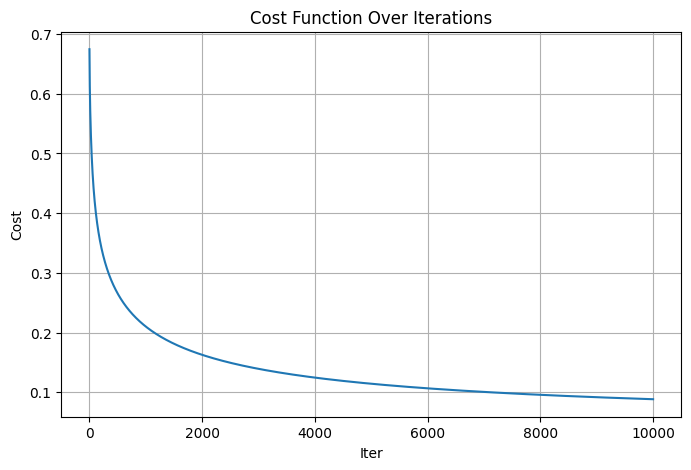

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.title('Cost Function Over Iterations')
plt.xlabel('Iter')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

In [13]:
# Predictions
def predict(X, w, b, threshold=0.5):
    z = X @ w + b
    h = sigmoid(z)
    return (h >= threshold).astype(int)

y_pred = predict(X_test, w, b)

# Accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix (manual)
tp = np.sum((y_pred == 1) & (y_test == 1))
tn = np.sum((y_pred == 0) & (y_test == 0))
fp = np.sum((y_pred == 1) & (y_test == 0))
fn = np.sum((y_pred == 0) & (y_test == 1))

print(f"\nConfusion Matrix:")
print(f"  TP={tp}  FP={fp}")
print(f"  FN={fn}  TN={tn}")

precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)

print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy: 89.40%

Confusion Matrix:
  TP=63  FP=12
  FN=11  TN=131

Precision: 0.8400
Recall:    0.8514
F1 Score:  0.8456


In [ ]:
def predict_spam(text):
    cleaned = clean(text)
    x = np.zeros((1, len(vocab)))
    for word in cleaned.split():
        if word in vocab:
            x[0, vocab[word]] += 1
    x = x / tra_max
    prob = sigmoid(x @ w + b)[0, 0]
    return f'{"SPAM" if prob >= 0.5 else "HAM"} (confidence: {prob:.4f})'

print(predict_spam('Congratulations you won a free prize click now'))
print(predict_spam('Hey are we meeting for lunch today'))
print(predict_spam('hurry! congratulation!! you just won a bmw prize car'))
print(predict_spam('Loose belly fat in 7 days! Send DIET to 38261 at N10 only'))
print(predict_spam('Dear colleague, your presence at the department meeting is needed'))
print(predict_spam('Get FREE unlimited data now! Send DATA to 33388!'))

SPAM (confidence: 0.9080)
HAM (confidence: 0.2859)
SPAM (confidence: 0.6190)
SPAM (confidence: 0.9042)
HAM (confidence: 0.0129)
SPAM (confidence: 0.8459)
